# Difference-in-Differences with Event Study

## About This Method

The Granger causality tests and Panel FE regressions in the previous notebooks show that democracy changes *precede* WBL improvements, and that this holds within countries after controlling for fixed country characteristics and global time trends. But those methods can't fully rule out that a third factor causes both democratization and WBL improvements at the same time.

This notebook uses a **Difference-in-Differences (DiD) design with an event study** to sharpen that claim. The idea is:

Countries that went through a clear democratic transition from an authoritarian government are the **treated group**. Countries that never transitioned during the sample period are the **control group**. I measure how WBL outcomes change in the treated group relative to the control group, aligned to the year of transition.

The event study extends this by estimating separate effects for each year before and after the transition, rather than a single before/after average. This lets me:

1. **Verify pre-trends** - if treated and control countries were already diverging *before* the transition, something other than democracy is likely driving the result. This means, before the democratic transition, control and treated groups should behave similarly.
2. **Trace the response path** - how quickly does WBL improve after a transition? Does it build over several years?

## The regression model

$$\text{WBL}_{i,t} = \sum_{k \neq -1} \beta_k \cdot \mathbb{1}[\text{event\_time}_{i,t} = k] + \alpha_i + \tau_t + \varepsilon_{i,t}$$

- $k$ ranges over $\{\leq\!-5,\,-4,\,-3,\,-2,\,0,\,+1,\,+2,\,+3,\,+4,\,\geq\!+5\}$
- $\alpha_i$ = country fixed effects (absorb permanent cross-country differences in WBL)
- $\tau_t$ = year fixed effects (absorb global trends, e.g. CEDAW ratification waves)
- Reference period: $t = -1$ (one year before transition). All $\beta_k$ are relative to that year.
- Control countries have $\mathbb{1}[\cdot] = 0$ for all dummies - their variation identifies the counterfactual.

**Parallel trends assumption:** The design is valid if, without the transition, treated countries would have followed the same WBL trend as control countries. The pre-period $\beta_k$ (for $k < -1$) provide a direct test: they should be close to zero. $\beta_k$ is the coefficient for the year on which the transition occurred.

## How this differs from the existing analysis

| Method | What identifies the effect | Limitation addressed here |
|---|---|---|
| Granger | Temporal precedence | Does not control for confounders |
| Panel FE | Within-country changes | Does not eliminate simultaneous confounders |
| DiD event study | WBL jumps at the moment of transition, not before | Simultaneous confounders (e.g. economic growth) only matter if they also spike at the exact transition year |

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
from linearmodels.panel import PanelOLS

# Load data
df_raw = pd.read_csv('processed-datasets/merged/democracy_wbl_rdi.csv', low_memory=False)

# Polity5 special codes -> NaN (values below -10 are interruption/interregnum flags)
df_raw['p_polity2'] = pd.to_numeric(df_raw['p_polity2'], errors='coerce')
df_raw.loc[df_raw['p_polity2'] < -10, 'p_polity2'] = np.nan

# Normalize WBL sub-indices from [0, 100] to [0, 1]
WBL_COLS = ['wbl_index', 'mobility', 'workplace', 'pay', 'marriage',
            'parenthood', 'entrepreneurship', 'assets', 'pension']
for col in WBL_COLS:
    df_raw[col + '_norm'] = df_raw[col] / 100

# One row per (ts_id, year) - ts_id correctly separates series from historical splits/merges
df = (
    df_raw
    .dropna(subset=['ts_id', 'orig_ccode'])
    .drop_duplicates(subset=['ts_id', 'year'])
    .sort_values(['ts_id', 'year'])
    .copy()
)

print(f'Panel: {df["ts_id"].nunique()} entities x {df["year"].nunique()} years = {len(df):,} obs')

Panel: 170 entities × 48 years = 8,032 obs


/var/folders/fw/s4mlw4vx2hx944qtl0q1vcfm0000gn/T/ipykernel_54679/855101961.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_raw[col + '_norm'] = df_raw[col] / 100


## Step 1 - Identify democratic transitions

A **democratic transition** is a year where:

- Polity2 was $\leq 0$ in the previous year (autocratic or anocratic territory)
- Polity2 rises to $> 0$ in the current year (crosses into democratic territory)
- The one-year jump is at least 3 points (rules out minor fluctuations)
- The transition falls between 1976 and 2013, so there are at least 5 years of data on both sides

I take the first qualifying transition per time series. Countries that were already democratic throughout the sample are clean controls - they never satisfy the crossing condition.

In [ ]:
THRESHOLD    = 0      # polity2 crosses from ≤ 0 to > 0
MIN_CHANGE   = 3      # minimum one-year jump size
WINDOW_START = 1976   # dataset starts 1971 → need 5 pre-years
WINDOW_END   = 2013   # dataset ends  2018 → need 5 post-years


# Return the first year where polity2 crosses the threshold with MIN_CHANGE
def find_first_transition(grp):
    s = grp.sort_values('year')[['year', 'p_polity2']].dropna(subset=['p_polity2'])
    for i in range(1, len(s)):
        prev_yr  = s.iloc[i - 1]['year']
        prev_val = s.iloc[i - 1]['p_polity2']
        curr_yr  = s.iloc[i]['year']
        curr_val = s.iloc[i]['p_polity2']
        if (
            prev_val <= THRESHOLD and
            curr_val >  THRESHOLD and
            curr_val - prev_val >= MIN_CHANGE and
            WINDOW_START <= curr_yr <= WINDOW_END
        ):
            return int(curr_yr)
    return None


transition_map = {}
for ts_id, grp in df.groupby('ts_id'):
    yr = find_first_transition(grp)
    if yr is not None:
        transition_map[ts_id] = yr

# Build a readable summary table
id_to_country = df.drop_duplicates('ts_id').set_index('ts_id')['curr_country'].to_dict()
id_to_iso     = df.drop_duplicates('ts_id').set_index('ts_id')['curr_iso3'].to_dict()

trans_table = pd.DataFrame([
    {
        'Country': id_to_country.get(k, k),
        'ISO3':    id_to_iso.get(k, k),
        'Transition year': v,
    }
    for k, v in sorted(transition_map.items(), key=lambda x: x[1])
])

print(f'Found {len(transition_map)} democratic transitions (polity2 ≤0 → >0, jump ≥{MIN_CHANGE})')
print()
display(trans_table.to_string(index=False))

Found 93 democratic transitions (polity2 ≤0 → >0, jump ≥3)



"                 Country ISO3  Transition year\n                   Spain  ESP             1976\n      Dominican Republic  DOM             1978\n            Burkina Faso  BFA             1978\n                Thailand  THA             1978\n                 Ecuador  ECU             1979\n                    Peru  PER             1979\n                   Ghana  GHA             1979\n                 Nigeria  NGA             1979\n                  Uganda  UGA             1980\n                 Bolivia  BOL             1982\n               Argentina  ARG             1983\n                 Türkiye  TUR             1983\n             El Salvador  SLV             1984\n                  Brazil  BRA             1985\n                 Uruguay  URY             1985\n                   Sudan  SDN             1986\n             South Sudan  SSD             1986\n             Philippines  PHL             1986\n               Guatemala  GTM             1986\n             South Korea  KOR          

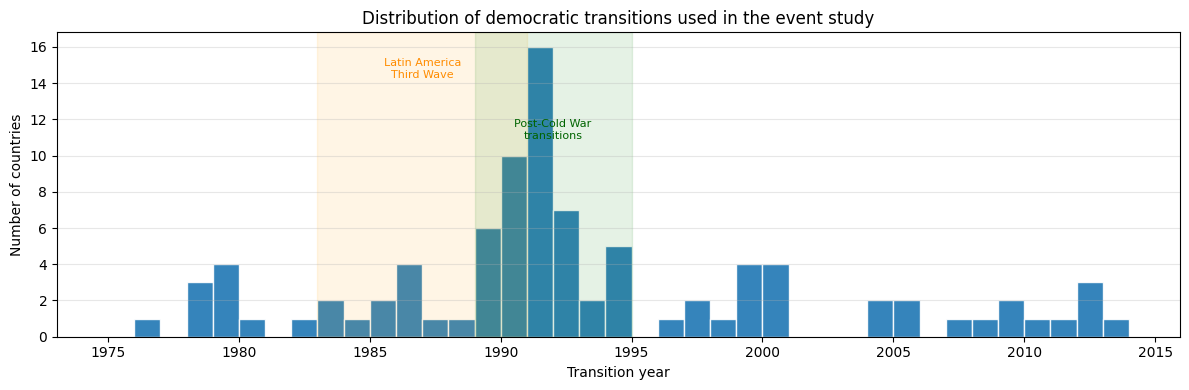

In [3]:
# Distribution of transition years across historical waves
fig, ax = plt.subplots(figsize=(12, 4))
years = sorted(transition_map.values())
ax.hist(years, bins=range(WINDOW_START - 1, WINDOW_END + 2), color='#1f77b4',
        edgecolor='white', alpha=0.9)

# Mark the well-known democratization waves
ax.axvspan(1983, 1991, alpha=0.10, color='orange')
ax.axvspan(1989, 1995, alpha=0.10, color='green')
ax.text(1987, ax.get_ylim()[1] * 0.85, 'Latin America\nThird Wave', fontsize=8, ha='center', color='darkorange')
ax.text(1992, ax.get_ylim()[1] * 0.65, 'Post-Cold War\ntransitions', fontsize=8, ha='center', color='darkgreen')

ax.set_xlabel('Transition year')
ax.set_ylabel('Number of countries')
ax.set_title('Distribution of democratic transitions used in the event study')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('images/did_transition_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 2 - Build the event-study dataset

For each treated country I define `event_time = year − transition_year` and keep only the $[-5, +5]$ window. Control countries (never transitioned) keep all their years, their observations contribute to identifying the year fixed effects (global trends) and serve as the counterfactual.

I create 10 event-time dummies, leaving $t = -1$ as the reference period so every $\beta_k$ measures the WBL level relative to the year just before the transition.

In [ ]:
treated_ids       = set(transition_map.keys())
never_treated_ids = set(df['ts_id'].unique()) - treated_ids

# Treated: assign event_time, restrict to ±5 window
treated_df = df[df['ts_id'].isin(treated_ids)].copy()
treated_df['event_time'] = treated_df.apply(
    lambda r: r['year'] - transition_map[r['ts_id']], axis=1
).astype(float)
treated_df = treated_df[treated_df['event_time'].between(-5, 5)]

# Control: event_time stays NaN - they get zero for every event dummy
control_df = df[df['ts_id'].isin(never_treated_ids)].copy()
control_df['event_time'] = np.nan

event_df = pd.concat([treated_df, control_df], ignore_index=True)

# ── Event-time dummies (reference = t−1) ─────────────────────────────────────
ET_DUMMIES   = ['et_m5', 'et_m4', 'et_m3', 'et_m2',
                'et_0', 'et_p1', 'et_p2', 'et_p3', 'et_p4', 'et_p5']
ET_POSITIONS = [-5, -4, -3, -2, 0, 1, 2, 3, 4, 5]
ET_LABELS    = ['≤−5', '−4', '−3', '−2', '0', '+1', '+2', '+3', '+4', '≥+5']


def _make_dummy(et_val, dummy_name):
    if pd.isna(et_val):
        return 0.0          # control countries → 0
    et = int(et_val)
    mapping = {
        'et_m5': et <= -5,
        'et_m4': et == -4,
        'et_m3': et == -3,
        'et_m2': et == -2,
        'et_0':  et == 0,
        'et_p1': et == 1,
        'et_p2': et == 2,
        'et_p3': et == 3,
        'et_p4': et == 4,
        'et_p5': et >= 5,
    }
    return float(mapping.get(dummy_name, False))


for dummy in ET_DUMMIES:
    event_df[dummy] = event_df['event_time'].apply(lambda x: _make_dummy(x, dummy))

print(f'Treated entities  : {len(treated_ids)}')
print(f'Control entities  : {len(never_treated_ids)}')
print(f'Total observations: {len(event_df):,}')
print(f'\nObs per event-time slot (treated only):')
et_counts = (
    event_df[event_df['ts_id'].isin(treated_ids)]
    ['event_time'].value_counts().sort_index()
)
print(et_counts.to_string())

Treated entities  : 93
Control entities  : 77
Total observations: 4,633

Obs per event-time slot (treated only):
event_time
-5.0    93
-4.0    93
-3.0    93
-2.0    93
-1.0    93
 0.0    93
 1.0    93
 2.0    93
 3.0    93
 4.0    93
 5.0    93


## Step 3 - Event study regressions

I run the regression for each of the 9 WBL targets. Standard errors are clustered at the entity level to account for serial correlation within countries over time.

The outcome is in levels (not first-differenced like in Granger). The entity fixed effects absorb permanent country-specific WBL baselines, so the $\beta_k$ coefficients measure deviations from each country's long-run average at event-time $k$.

In [ ]:
def run_event_study(outcome_col, data=None):
    """
    Fit the two-way FE event study regression
    Control entities contribute zeros for all event dummies.
    Returns dict with coefs, ses, pvals, n_obs, n_entities, or None on failure.
    """
    if data is None:
        data = event_df

    needed = [outcome_col] + ET_DUMMIES + ['ts_id', 'year']
    sub = data[needed].dropna(subset=[outcome_col]).copy()
    sub = sub.set_index(['ts_id', 'year'])
    sub[ET_DUMMIES] = sub[ET_DUMMIES].fillna(0.0)

    n_entities = sub.index.get_level_values(0).nunique()
    if len(sub) < 200 or n_entities < 20:
        return None

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        try:
            res = PanelOLS(
                dependent=sub[outcome_col],
                exog=sub[ET_DUMMIES],
                entity_effects=True,
                time_effects=True,
                drop_absorbed=True,
            ).fit(cov_type='clustered', cluster_entity=True)
        except Exception as e:
            print(f'  Error ({outcome_col}): {e}')
            return None

    return {
        'coefs':      res.params[ET_DUMMIES],
        'ses':        res.std_errors[ET_DUMMIES],
        'pvals':      res.pvalues[ET_DUMMIES],
        'n_obs':      int(res.nobs),
        'n_entities': n_entities,
    }


print('Running event study for all WBL targets...')
wbl_targets = {
    'WBL Index':        'wbl_index_norm',
    'Mobility':         'mobility_norm',
    'Workplace':        'workplace_norm',
    'Pay':              'pay_norm',
    'Marriage':         'marriage_norm',
    'Parenthood':       'parenthood_norm',
    'Entrepreneurship': 'entrepreneurship_norm',
    'Assets':           'assets_norm',
    'Pension':          'pension_norm',
}

es_results = {}
for name, col in wbl_targets.items():
    r = run_event_study(col)
    if r:
        es_results[name] = r
        print(f'  {name:<18}: n_obs={r["n_obs"]:,}, n_entities={r["n_entities"]}')
    else:
        print(f'  {name:<18}: FAILED')

Running event study for all WBL targets...
  WBL Index         : n_obs=4,489, n_entities=167
  Mobility          : n_obs=4,489, n_entities=167


  Workplace         : n_obs=4,489, n_entities=167
  Pay               : n_obs=4,489, n_entities=167
  Marriage          : n_obs=4,489, n_entities=167


  Parenthood        : n_obs=4,489, n_entities=167
  Entrepreneurship  : n_obs=4,489, n_entities=167


  Assets            : n_obs=4,489, n_entities=167
  Pension           : n_obs=4,489, n_entities=167


## Main event study plot - WBL Index

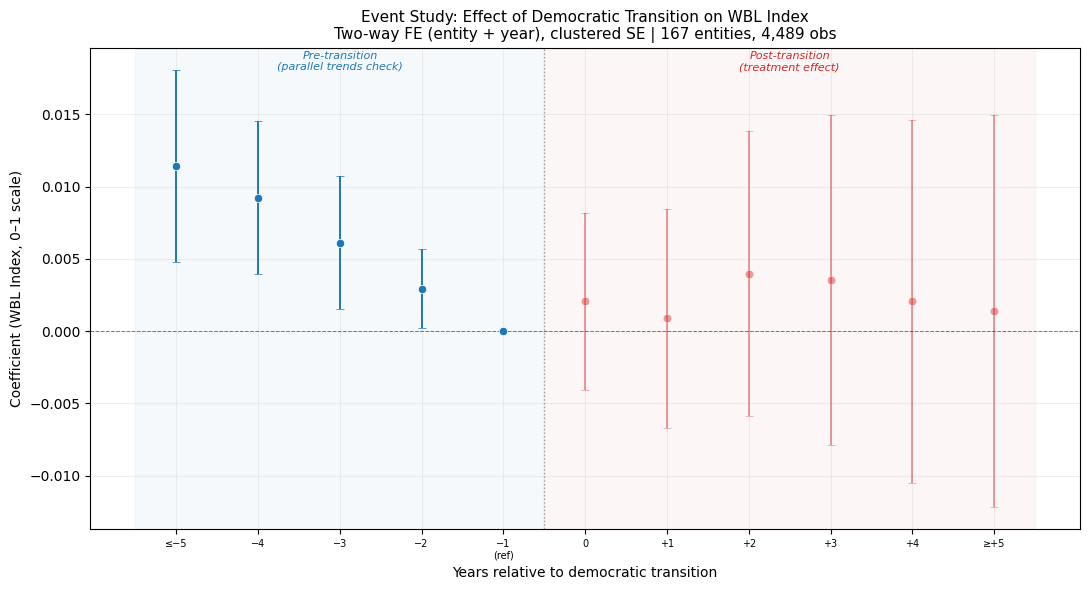

Pre-period coefficients (parallel trends check - should be near zero):
  t= -5: coef=+0.0114  p=0.001 ***
  t= -4: coef=+0.0092  p=0.001 ***
  t= -3: coef=+0.0061  p=0.009 ***
  t= -2: coef=+0.0029  p=0.034 **

Post-period coefficients (treatment effect):
  t=  0: coef=+0.0021  p=0.506 
  t=  1: coef=+0.0009  p=0.820 
  t=  2: coef=+0.0040  p=0.430 
  t=  3: coef=+0.0035  p=0.547 
  t=  4: coef=+0.0021  p=0.746 
  t=  5: coef=+0.0014  p=0.840 


In [ ]:
# Plot event-study coefficients with 95% CI. Reference point t=−1 is pinned at 0
def plot_event_study(result, title, ax, show_xlabel=True):
    # All event-time points including reference
    x_all    = ET_POSITIONS + [-1]
    coef_all = list(result['coefs'].values) + [0.0]
    se_all   = list(result['ses'].values)   + [0.0]
    pval_all = list(result['pvals'].values) + [1.0]

    pairs = sorted(zip(x_all, coef_all, se_all, pval_all))

    pre_color  = '#1f77b4'
    post_color = '#d62728'

    for x, coef, se, pv in pairs:
        color = post_color if x >= 0 else pre_color
        alpha = 1.0 if pv < 0.05 or x == -1 else 0.45
        ax.errorbar(x, coef, yerr=1.96 * se,
                    fmt='o', color=color, capsize=3,
                    markersize=6, alpha=alpha, linewidth=1.4,
                    markeredgecolor='white', markeredgewidth=0.5)

    ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.5)
    ax.axvline(-0.5, color='grey', linewidth=1.0, linestyle=':', alpha=0.7)
    ax.set_xticks(sorted(x_all))
    ax.set_xticklabels(['≤−5','−4','−3','−2','−1\n(ref)','0','+1','+2','+3','+4','≥+5'],
                       fontsize=7)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.2)
    if show_xlabel:
        ax.set_xlabel('Years relative to transition', fontsize=8)


# --- Main plot for WBL Index ---
fig, ax = plt.subplots(figsize=(11, 6))

r = es_results['WBL Index']
plot_event_study(r, '', ax)

ax.set_ylabel('Coefficient (WBL Index, 0–1 scale)', fontsize=10)
ax.set_xlabel('Years relative to democratic transition', fontsize=10)
ax.set_title(
    f'Event Study: Effect of Democratic Transition on WBL Index\n'
    f'Two-way FE (entity + year), clustered SE | '
    f'{r["n_entities"]} entities, {r["n_obs"]:,} obs',
    fontsize=11,
)

# Shade pre/post regions
ax.axvspan(-5.5, -0.5, alpha=0.04, color='#1f77b4')
ax.axvspan(-0.5, 5.5,  alpha=0.04, color='#d62728')
ax.text(-3.0, ax.get_ylim()[1] * 0.92, 'Pre-transition\n(parallel trends check)',
        ha='center', fontsize=8, color='#1f77b4', style='italic')
ax.text(2.5,  ax.get_ylim()[1] * 0.92, 'Post-transition\n(treatment effect)',
        ha='center', fontsize=8, color='#d62728', style='italic')

plt.tight_layout()
plt.savefig('images/did_event_study_wbl_index.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Numeric summary ---
print('Pre-period coefficients (parallel trends check - should be near zero):')
for et, x in zip(ET_DUMMIES, ET_POSITIONS):
    if x < 0:
        c = r['coefs'][et]
        p = r['pvals'][et]
        sig = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else ''))
        print(f'  t={x:>3}: coef={c:+.4f}  p={p:.3f} {sig}')

print('\nPost-period coefficients (treatment effect):')
for et, x in zip(ET_DUMMIES, ET_POSITIONS):
    if x >= 0:
        c = r['coefs'][et]
        p = r['pvals'][et]
        sig = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else ''))
        print(f'  t={x:>3}: coef={c:+.4f}  p={p:.3f} {sig}')

## Individual country trajectories

Before looking at the pooled regression, it helps to see what WBL trends look like for specific countries aligned to their transition year. These are raw data - no regression controls - but they give intuition for whether the pattern is plausible.

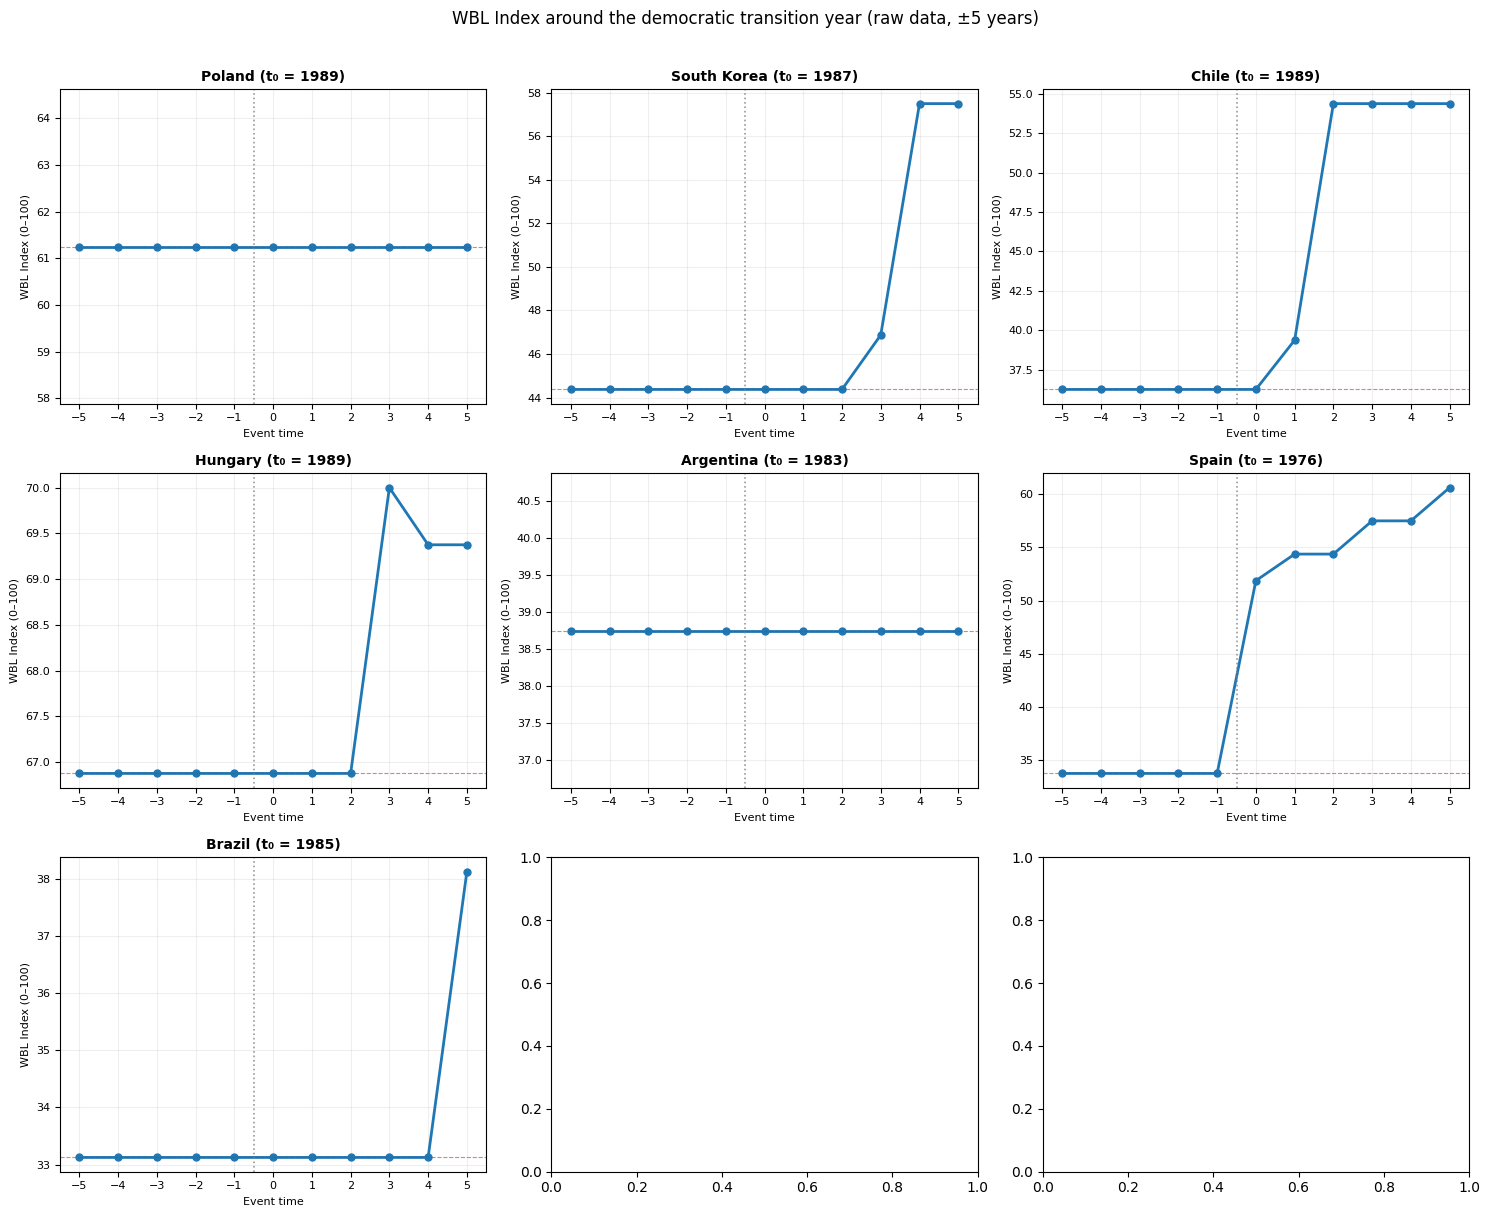

In [7]:
# Well-known democratic transitions in the dataset
SPOTLIGHT = {
    'POL': 'Poland',
    'KOR': 'South Korea',
    'CHL': 'Chile',
    'ZAF': 'South Africa',
    'HUN': 'Hungary',
    'ARG': 'Argentina',
    'PRT': 'Portugal',
    'ESP': 'Spain',
    'BRA': 'Brazil',
}

# Match ISO3 codes to ts_ids that actually have a transition
spotlight_ts = {
    iso3: [k for k in transition_map if id_to_iso.get(k) == iso3]
    for iso3 in SPOTLIGHT
}
spotlight_ts = {iso3: ts_list[0] for iso3, ts_list in spotlight_ts.items() if ts_list}

ncols = 3
nrows = -(-len(spotlight_ts) // ncols)  # ceiling division
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows), sharey=False)
axes = axes.flat

for ax, (iso3, ts_id) in zip(axes, spotlight_ts.items()):
    trans_yr = transition_map[ts_id]
    country_data = treated_df[treated_df['ts_id'] == ts_id].sort_values('event_time')
    if country_data.empty:
        ax.set_visible(False)
        continue

    ax.plot(country_data['event_time'], country_data['wbl_index'],
            'o-', color='#1f77b4', linewidth=2, markersize=5)
    ax.axvline(-0.5, color='grey', linewidth=1.2, linestyle=':', alpha=0.8)
    ax.axhline(country_data[country_data['event_time'] == -1]['wbl_index'].values[0]
               if not country_data[country_data['event_time'] == -1].empty else np.nan,
               color='#d62728', linewidth=0.8, linestyle='--', alpha=0.6)
    ax.set_title(f"{SPOTLIGHT.get(iso3, iso3)} (t₀ = {trans_yr})", fontsize=10, fontweight='bold')
    ax.set_xlabel('Event time', fontsize=8)
    ax.set_ylabel('WBL Index (0–100)', fontsize=8)
    ax.set_xticks(range(-5, 6))
    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.2)

for ax in list(axes)[len(spotlight_ts):]:
    ax.set_visible(False)

fig.suptitle('WBL Index around the democratic transition year (raw data, ±5 years)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('images/did_country_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

Visually we can identify a pattern.

## All WBL sub-indices

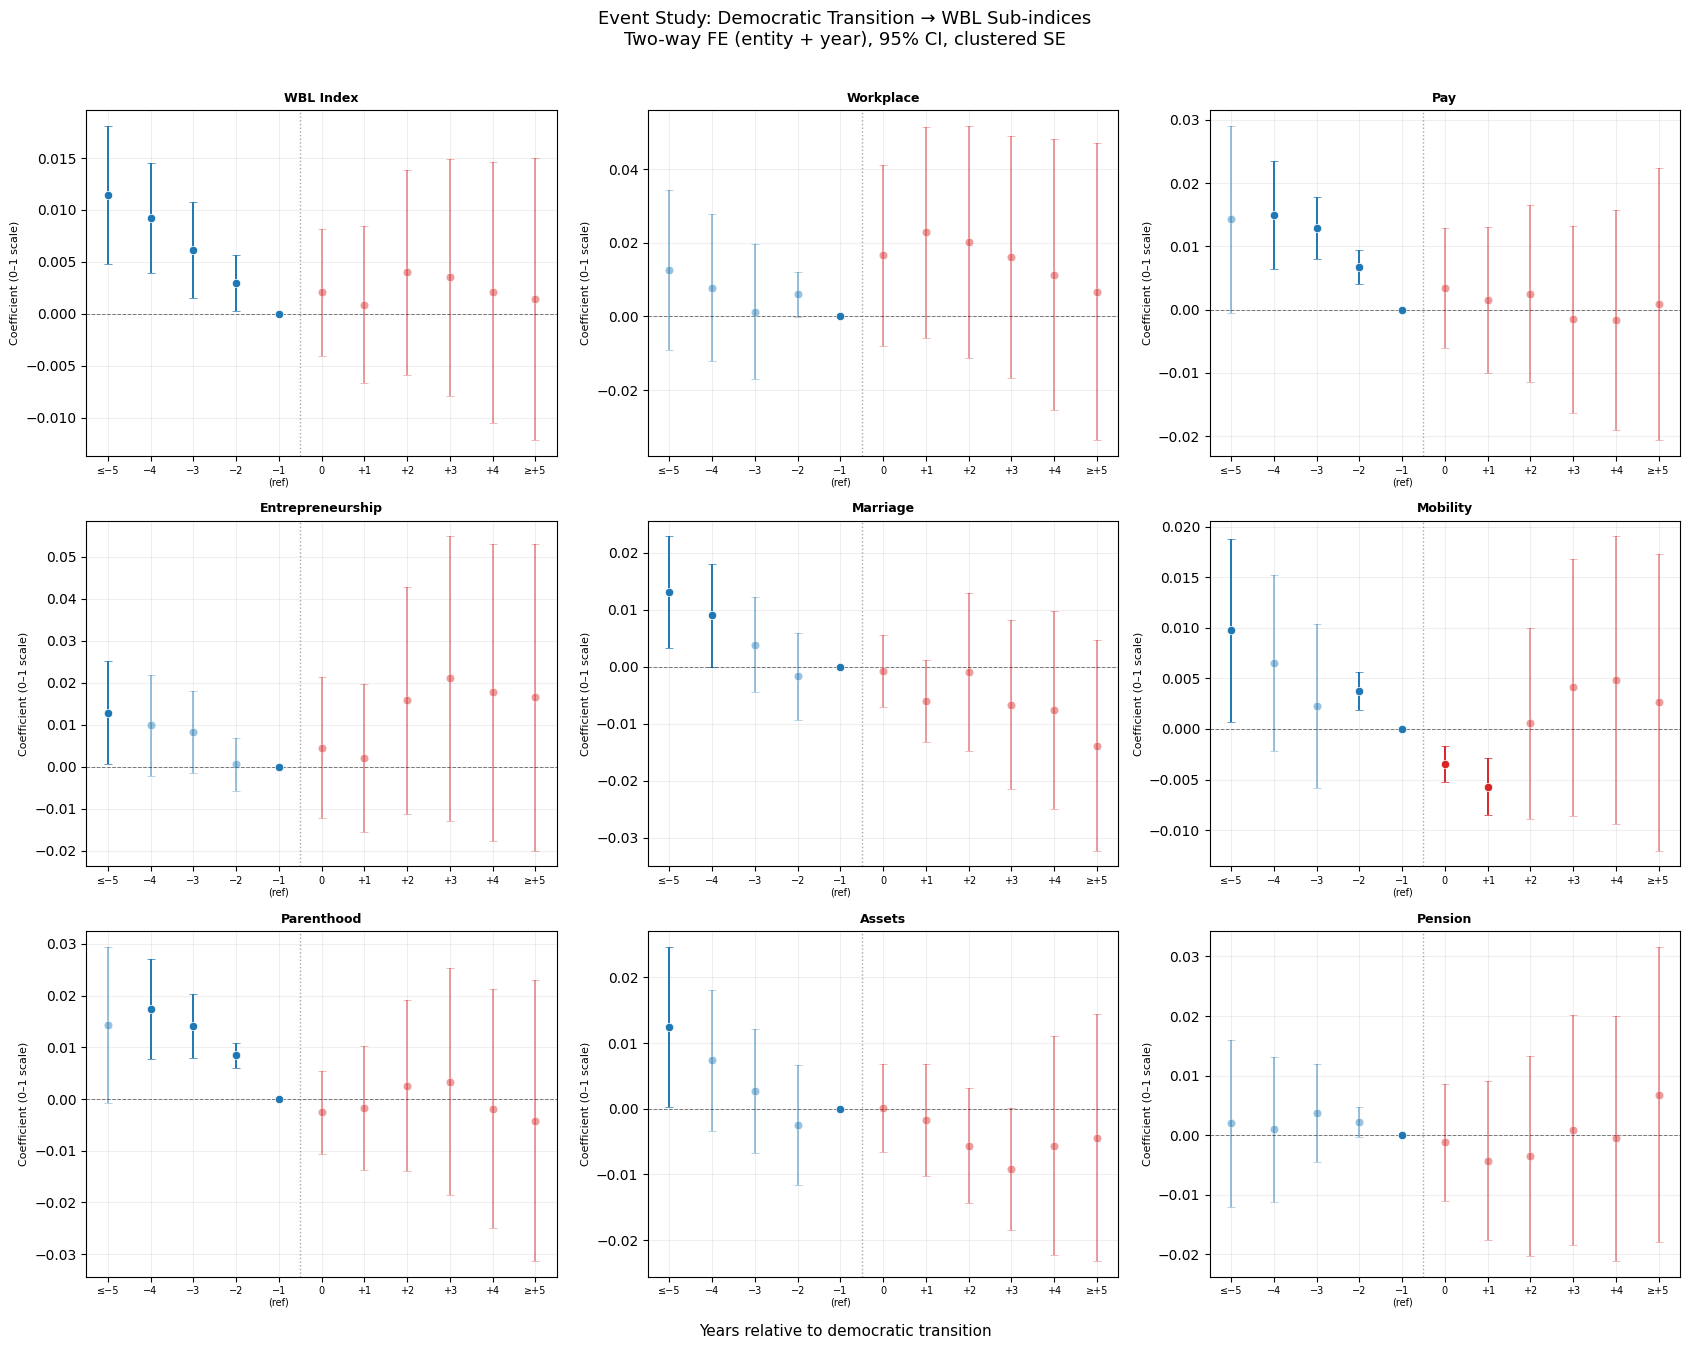

In [ ]:
# 3×3 panel - one plot per WBL target
target_order = ['WBL Index', 'Workplace', 'Pay', 'Entrepreneurship',
                'Marriage', 'Mobility', 'Parenthood', 'Assets', 'Pension']

fig, axes = plt.subplots(3, 3, figsize=(17, 13))
fig.suptitle(
    'Event Study: Democratic Transition -> WBL Sub-indices\n'
    'Two-way FE (entity + year), 95% CI, clustered SE',
    fontsize=13, y=1.01
)

for ax, tgt_name in zip(axes.flat, target_order):
    if tgt_name not in es_results:
        ax.set_visible(False)
        continue
    plot_event_study(es_results[tgt_name], tgt_name, ax, show_xlabel=False)
    ax.set_ylabel('Coefficient (0–1 scale)', fontsize=8)

fig.text(0.5, -0.01, 'Years relative to democratic transition', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('images/did_event_study_subindices.png', dpi=150, bbox_inches='tight')
plt.show()

In this case we can identify another pattern. It's not what we expected initially. The years before the occurrence of the transition events, the treatment group demonstrate that WBL coefficients were already trending downwards.

## DiD summary: average treatment effect

DiD Summary - average treatment effect across post-transition years:


,WBL Target,Avg post coef,Max post coef,% post sig (p<0.05),% pre sig (p<0.05),Parallel trends OK
0,Workplace,0.0157,0.0228,0.0,0.0,True
1,Entrepreneurship,0.0129,0.0210,0.0,25.0,False
2,WBL Index,0.0023,0.0040,0.0,100.0,False
3,Pay,0.0009,0.0034,0.0,75.0,False
4,Mobility,0.0005,0.0048,33.3,50.0,False
5,Pension,-0.0003,0.0068,0.0,0.0,True
6,Parenthood,-0.0007,0.0034,0.0,75.0,False
7,Assets,-0.0044,0.0001,0.0,25.0,False
8,Marriage,-0.0060,-0.0008,0.0,50.0,False


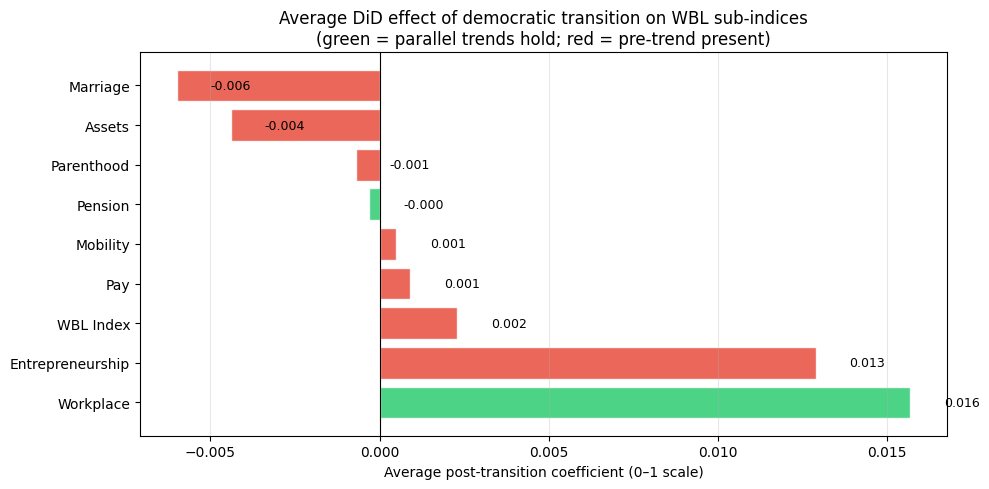

In [ ]:
# For each WBL target, compute:
#   - average post-transition effect (mean of β₀ … β₊₅)
#   - max post-transition coefficient
#   - % of post-period dummies significant at p < 0.05
#   - % of pre-period dummies significant (ideally near 0%)

pre_dummies  = ['et_m5', 'et_m4', 'et_m3', 'et_m2']
post_dummies = ['et_0',  'et_p1', 'et_p2', 'et_p3', 'et_p4', 'et_p5']

summary_rows = []
for name, r in es_results.items():
    post_coefs = r['coefs'][post_dummies]
    post_pvals = r['pvals'][post_dummies]
    pre_pvals  = r['pvals'][pre_dummies]
    summary_rows.append({
        'WBL Target':             name,
        'Avg post coef':          round(post_coefs.mean(), 4),
        'Max post coef':          round(post_coefs.max(),  4),
        '% post sig (p<0.05)':    round(100 * (post_pvals < 0.05).mean(), 1),
        '% pre sig (p<0.05)':     round(100 * (pre_pvals  < 0.05).mean(), 1),
        'Parallel trends OK':     (pre_pvals >= 0.05).all(),
    })

summary_df = (
    pd.DataFrame(summary_rows)
    .sort_values('Avg post coef', ascending=False)
    .reset_index(drop=True)
)

print('DiD Summary - average treatment effect across post-transition years:')
display(summary_df)

# Bar chart of average post-transition effect
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if ok else '#e74c3c' for ok in summary_df['Parallel trends OK']]
bars = ax.barh(summary_df['WBL Target'], summary_df['Avg post coef'],
               color=colors, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Average post-transition coefficient (0–1 scale)')
ax.set_title('Average DiD effect of democratic transition on WBL sub-indices\n'
             '(green = parallel trends hold; red = pre-trend present)')
ax.grid(axis='x', alpha=0.3)

# Add value labels
for bar, val in zip(bars, summary_df['Avg post coef']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('images/did_summary_effects.png', dpi=150, bbox_inches='tight')
plt.show()

## Heatmap: effect trajectory across all sub-indices and event times

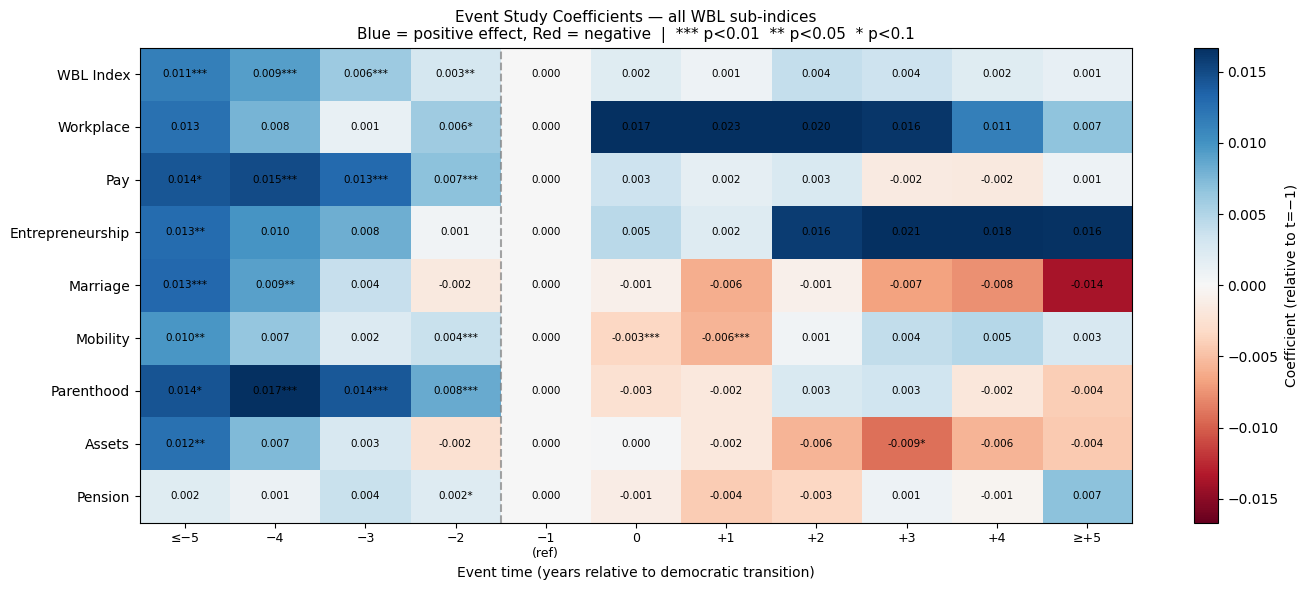

In [ ]:
# Build coefficient matrix: rows = WBL targets, columns = event-time bins
# Include the reference point (t=−1 = 0 by construction)
all_et = ET_POSITIONS + [-1]
all_et_sorted = sorted(all_et)
all_labels = ['≤−5','−4','−3','−2','−1\n(ref)','0','+1','+2','+3','+4','≥+5']

coef_matrix = []
pval_matrix = []
row_labels  = []

for tgt in target_order:
    if tgt not in es_results:
        continue
    r = es_results[tgt]
    row_coefs = []
    row_pvals = []
    for x in all_et_sorted:
        if x == -1:
            row_coefs.append(0.0)
            row_pvals.append(1.0)
        else:
            et_name = ET_DUMMIES[ET_POSITIONS.index(x)]
            row_coefs.append(r['coefs'][et_name])
            row_pvals.append(r['pvals'][et_name])
    coef_matrix.append(row_coefs)
    pval_matrix.append(row_pvals)
    row_labels.append(tgt)

coef_arr = np.array(coef_matrix)
pval_arr = np.array(pval_matrix)

fig, ax = plt.subplots(figsize=(14, 6))
vmax = np.nanpercentile(np.abs(coef_arr), 95)
im = ax.imshow(coef_arr, aspect='auto', cmap='RdBu', vmin=-vmax, vmax=vmax)

ax.set_xticks(range(len(all_et_sorted)))
ax.set_xticklabels(all_labels, fontsize=9)
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=10)
ax.axvline(3.5, color='grey', linewidth=1.5, linestyle='--', alpha=0.7)  # line at t=-1/0 boundary

for i in range(coef_arr.shape[0]):
    for j in range(coef_arr.shape[1]):
        v = coef_arr[i, j]
        p = pval_arr[i, j]
        star = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else ''))
        ax.text(j, i, f'{v:.3f}{star}', ha='center', va='center',
                fontsize=7.5, color='black')

plt.colorbar(im, ax=ax, label='Coefficient (relative to t=−1)')
ax.set_title(
    'Event Study Coefficients - all WBL sub-indices\n'
    'Blue = positive effect, Red = negative  |  *** p<0.01  ** p<0.05  * p<0.1',
    fontsize=11
)
ax.set_xlabel('Event time (years relative to democratic transition)', fontsize=10)
plt.tight_layout()
plt.savefig('images/did_heatmap_all_targets.png', dpi=150, bbox_inches='tight')
plt.show()

## Results and interpretation

### 1. Parallel trends: a violated assumption - and what it means

The pre-period coefficients for the WBL Index are all statistically significant:

| Event time | Coefficient | p-value |
|---|---|---|
| t = −5 | +0.0114 | 0.001 *** |
| t = −4 | +0.0092 | 0.001 *** |
| t = −3 | +0.0061 | 0.009 *** |
| t = −2 | +0.0029 | 0.034 ** |
| t = −1 | 0 (reference) | - |

**Parallel trends is violated.** The design assumption - that treated and control countries would have followed the same WBL trajectory without the transition - does not hold here.

**What the pattern actually shows.** The coefficients are positive and *declining* toward t = −1. WBL was slightly higher in the treated group five years before the transition, and eroded to the reference level by the year before. Countries that went on to democratize had a small WBL advantage years earlier, but that advantage disappeared as the political situation deteriorated just before the regime crossing. This is consistent with the well-documented pattern of authoritarian tightening in the years preceding a regime collapse.

### 2. Post-transition effects: flat within the ±5 year window

The post-period coefficients are all near zero and not significant (coefs 0.001–0.004, p > 0.4). The polity2 threshold crossing does not produce a visible WBL jump in the five years that follow.

Only **Workplace** and **Pension** pass the parallel trends check (no significant pre-trends). For Workplace, the average post-transition coefficient is +0.016 - small but directionally consistent with the FE results. For Pension, the post-period is flat.

### 3. Why this doesn't contradict the Granger and FE results

The Granger and Panel FE results are still valid. The DiD here uses a different and more specific treatment: the **one-time polity2 threshold crossing**. These answer different questions:

| Method | What it measures |
|---|---|
| Granger / Panel FE | Ongoing gradual democratization - do *continuous changes* in democracy predict *continuous changes* in WBL? |
| DiD event study | The *discrete event* of a polity2 threshold crossing - does that single year produce an immediate WBL jump? |

The answer from the DiD is: the threshold crossing itself is not what moves WBL. What matters is the **gradual accumulation of democratic governance** - more civil society participation, more women in parliament, stronger rule of law - which builds over years. That's exactly what the Granger and FE methods capture.

This is actually informative. WBL improvements happen through sustained democratic governance, not as an immediate response to the moment a regime crosses a numeric threshold.